# Data Pre-processing Pipelines: Image, Text, Audio, Time-series, Tabular

In [ ]:
!pip install -q librosa opencv-python-headless


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

NumPy version: 2.0.2
Pandas version: 2.2.3


# Part 1 : Image Data

## 1.1 Loading & Inspecting an Image



Type : <class 'numpy.ndarray'>
Shape: (342, 548, 3)
dtype: uint8
Min / Max pixel value: 0 255


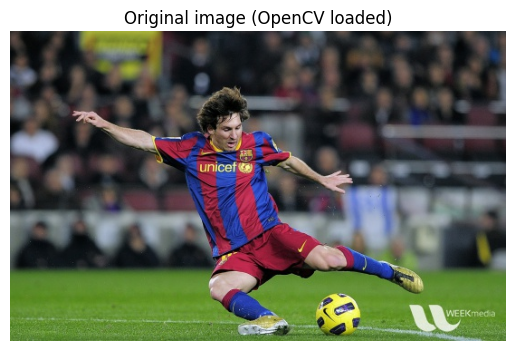

In [ ]:
import cv2
from urllib.request import urlretrieve

url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/messi5.jpg"
img_path = "sample_image.jpg"
urlretrieve(url, img_path)

img_bgr = cv2.imread(img_path)
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Type :", type(img))
print("Shape:", img.shape)
print("dtype:", img.dtype)
print("Min / Max pixel value:", img.min(), img.max())

plt.imshow(img)
plt.title("Original image")
plt.axis("off")
plt.show()


## 1.2 Resizing

Models need a fixed input size. With OpenCV, use `cv2.resize`. OpenCV uses `(width, height)` order.


Resized shape: (128, 128, 3)
Resized dtype: uint8 range: 1 - 252


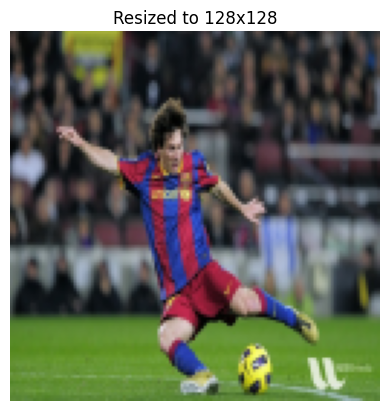

In [ ]:
img_resized = cv2.resize(img, (128, 128), interpolation=cv2.INTER_AREA)

print("Resized shape:", img_resized.shape)
print("Resized dtype:", img_resized.dtype, "range:", img_resized.min(), "-", img_resized.max())

plt.imshow(img_resized)
plt.title("Resized to 128x128")
plt.axis("off")
plt.show()


## 1.3 Normalization

Two common choices:
* **[0, 1] scaling** — divide by 255
* **Standardization** — subtract dataset mean, divide by dataset std (per channel)

In [ ]:
img_uint8 = img_resized

# Scale to [0, 1]
img_scaled = img_uint8.astype(np.float32) / 255.0
print("Scaled range:", img_scaled.min(), "-", img_scaled.max())

# Standardize (zero mean, unit variance) — per channel
mean = img_scaled.mean(axis=(0, 1))
std = img_scaled.std(axis=(0, 1))
img_standardized = (img_scaled - mean) / std

print("Per-channel mean:", mean)
print("Per-channel std :", std)
print("Standardized mean:", img_standardized.mean(axis=(0, 1)))
print("Standardized std :", img_standardized.std(axis=(0, 1)))


Scaled range: 0.003921569 - 0.9882353
Per-channel mean: [0.3222153  0.33745322 0.28396246]
Per-channel std : [0.18109499 0.19922742 0.17260523]
Standardized mean: [ 1.2370299e-05 -2.2986838e-05 -3.6769859e-05]
Standardized std : [0.9999936  1.0000095  0.99998975]


## 1.4 Color Space Conversion (RGB → Grayscale)

Grayscale shape: (128, 128)


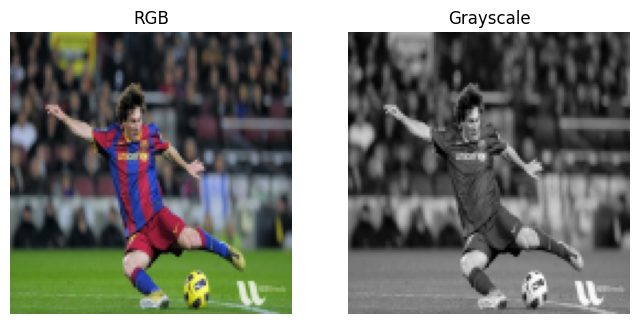

In [ ]:
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
print("Grayscale shape:", img_gray.shape)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_resized); axes[0].set_title("RGB"); axes[0].axis("off")
axes[1].imshow(img_gray, cmap="gray"); axes[1].set_title("Grayscale"); axes[1].axis("off")
plt.show()


## 1.5 Data Augmentation

Augmentation artificially expands a training set by applying label-preserving transforms — helps prevent overfitting.

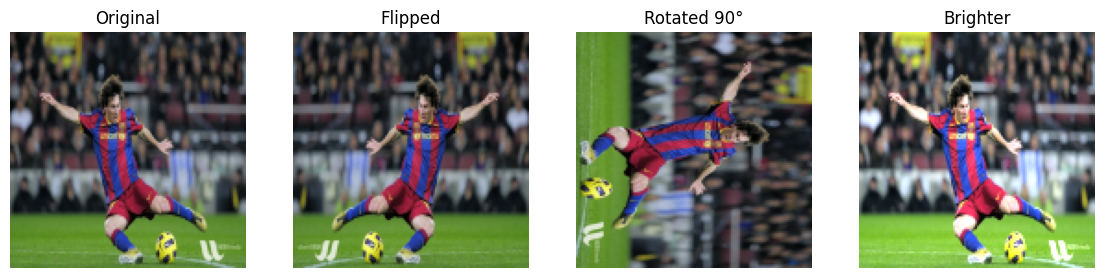

In [ ]:
img_flipped = cv2.flip(img_resized, 1)
img_rotated = cv2.rotate(img_resized, cv2.ROTATE_90_CLOCKWISE)
img_brighter = cv2.convertScaleAbs(img_resized, alpha=1.4, beta=0)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, im, title in zip(
    axes,
    [img_resized, img_flipped, img_rotated, img_brighter],
    ["Original", "Flipped", "Rotated 90°", "Brighter"],
):
    ax.imshow(im); ax.set_title(title); ax.axis("off")
plt.show()


## 1.6 Shaping for a Model

Deep learning frameworks expect a **batch** dimension, and PyTorch expects **channels-first** (`C, H, W`) while TensorFlow/Keras expects **channels-last** (`H, W, C`).

In [ ]:
# Channels-last batch (Keras/TF style): (batch, H, W, C)
batch_tf = np.expand_dims(img_resized, axis=0)
print("TF-style batch shape:", batch_tf.shape)

# Channels-first batch (PyTorch style): (batch, C, H, W)
img_chw = np.transpose(img_resized, (2, 0, 1))   # move channel axis to front
batch_torch = np.expand_dims(img_chw, axis=0)
print("PyTorch-style batch shape:", batch_torch.shape)

TF-style batch shape: (1, 128, 128, 3)
PyTorch-style batch shape: (1, 3, 128, 128)


# Part 2 — Text Data

## 2.1 Raw Text

In [ ]:
corpus = [
    "The quick brown fox jumps over the lazy dog!",
    "Machine learning models LOVE clean data...",
    "Data pre-processing is, arguably, the most important step in ML.",
    "NLP pipelines convert raw text into numeric features.",
]
for c in corpus:
    print("-", c)

- The quick brown fox jumps over the lazy dog!
- Machine learning models LOVE clean data...
- Data pre-processing is, arguably, the most important step in ML.
- NLP pipelines convert raw text into numeric features.


## 2.2 Lowercasing & Punctuation Removal

In [ ]:
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

cleaned = [clean_text(c) for c in corpus]
for original, c in zip(corpus, cleaned):
    print(f"{original!r}\n  -> {c!r}\n")

'The quick brown fox jumps over the lazy dog!'
  -> 'the quick brown fox jumps over the lazy dog'

'Machine learning models LOVE clean data...'
  -> 'machine learning models love clean data'

'Data pre-processing is, arguably, the most important step in ML.'
  -> 'data preprocessing is arguably the most important step in ml'

'NLP pipelines convert raw text into numeric features.'
  -> 'nlp pipelines convert raw text into numeric features'



## 2.3 Tokenization

In [ ]:
import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
from nltk.tokenize import word_tokenize

tokens = [word_tokenize(c) for c in cleaned]
for t in tokens:
    print(t)

['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']
['machine', 'learning', 'models', 'love', 'clean', 'data']
['data', 'preprocessing', 'is', 'arguably', 'the', 'most', 'important', 'step', 'in', 'ml']
['nlp', 'pipelines', 'convert', 'raw', 'text', 'into', 'numeric', 'features']


## 2.4 Stopword Removal

Stopwords ("the", "is", "a", ...) carry little topical meaning and are often dropped.

In [ ]:
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))
tokens_no_stop = [[w for w in t if w not in stop_words] for t in tokens]

for before, after in zip(tokens, tokens_no_stop):
    print(before, "->", after)

['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog'] -> ['quick', 'brown', 'fox', 'jumps', 'lazy', 'dog']
['machine', 'learning', 'models', 'love', 'clean', 'data'] -> ['machine', 'learning', 'models', 'love', 'clean', 'data']
['data', 'preprocessing', 'is', 'arguably', 'the', 'most', 'important', 'step', 'in', 'ml'] -> ['data', 'preprocessing', 'arguably', 'important', 'step', 'ml']
['nlp', 'pipelines', 'convert', 'raw', 'text', 'into', 'numeric', 'features'] -> ['nlp', 'pipelines', 'convert', 'raw', 'text', 'numeric', 'features']


## 2.5 Stemming vs Lemmatization

* **Stemming** : crude chopping of word endings (fast, sometimes not a real word)
* **Lemmatization** : dictionary-aware reduction to the base/root form (slower, more accurate)

In [ ]:
nltk.download("wordnet", quiet=True)
from nltk.stem import PorterStemmer, WordNetLemmatizer

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

sample = tokens_no_stop[1]
print("Original :", sample)
print("Stemmed  :", [stemmer.stem(w) for w in sample])
print("Lemmatized:", [lemmatizer.lemmatize(w) for w in sample])

Original : ['machine', 'learning', 'models', 'love', 'clean', 'data']
Stemmed  : ['machin', 'learn', 'model', 'love', 'clean', 'data']
Lemmatized: ['machine', 'learning', 'model', 'love', 'clean', 'data']


## 2.6 Bag-of-Words (Count Vectorization)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
bow = vectorizer.fit_transform(cleaned)

print("Vocabulary:", vectorizer.get_feature_names_out())
print("\nBag-of-words matrix (docs x vocab):\n", bow.toarray())
print("\nShape:", bow.shape)

Vocabulary: ['arguably' 'brown' 'clean' 'convert' 'data' 'dog' 'features' 'fox'
 'important' 'in' 'into' 'is' 'jumps' 'lazy' 'learning' 'love' 'machine'
 'ml' 'models' 'most' 'nlp' 'numeric' 'over' 'pipelines' 'preprocessing'
 'quick' 'raw' 'step' 'text' 'the']

Bag-of-words matrix (docs x vocab):
 [[0 1 0 0 0 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 2]
 [0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 1 0 1]
 [0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 1 0 1 0]]

Shape: (4, 30)


## 2.7 TF-IDF

Term Frequency–Inverse Document Frequency down-weights words that appear in many documents (less informative) and up-weights rarer, more distinctive words.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
tfidf = tfidf_vectorizer.fit_transform(cleaned)

tfidf_df = pd.DataFrame(tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
tfidf_df.round(2)

,arguably,brown,clean,convert,data,dog,features,fox,important,in,...,nlp,numeric,over,pipelines,preprocessing,quick,raw,step,text,the
0,0.00,0.32,0.00,0.00,0.00,0.32,0.00,0.32,0.00,0.00,...,0.00,0.00,0.32,0.00,0.00,0.32,0.00,0.00,0.00,0.51
1,0.00,0.00,0.42,0.00,0.33,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,0.33,0.00,0.00,0.00,0.26,0.00,0.00,0.00,0.33,0.33,...,0.00,0.00,0.00,0.00,0.33,0.00,0.00,0.33,0.00,0.26
3,0.00,0.00,0.00,0.35,0.00,0.00,0.35,0.00,0.00,0.00,...,0.35,0.35,0.00,0.35,0.00,0.00,0.35,0.00,0.35,0.00


# Part 3 : Audio Data

## 3.1 Loading a Waveform

Waveform shape: (44100,)
Sample rate   : 22050 Hz
Duration      : 2.0 s


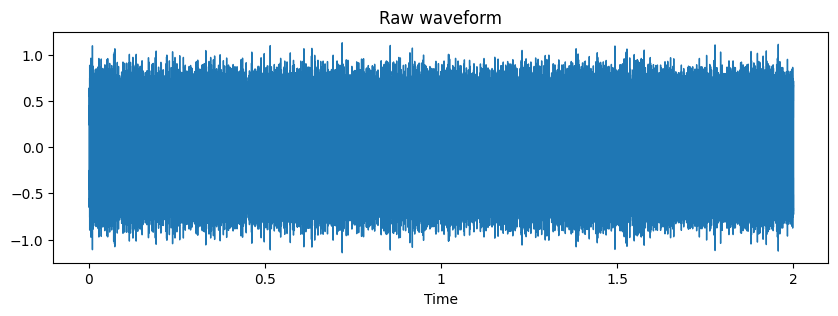

In [ ]:
import librosa
import librosa.display

sr = 22050              # sample rate: samples per second
duration = 2.0          # seconds
t = np.linspace(0, duration, int(sr * duration), endpoint=False)

waveform = 0.6 * np.sin(2 * np.pi * 440 * t)                 # 440 Hz tone (musical note A4)
waveform += 0.15 * np.random.randn(len(t))                   # additive noise

print("Waveform shape:", waveform.shape)
print("Sample rate   :", sr, "Hz")
print("Duration      :", len(waveform) / sr, "s")

plt.figure(figsize=(10, 3))
librosa.display.waveshow(waveform, sr=sr)
plt.title("Raw waveform")
plt.show()

## 3.2 Resampling

Datasets often mix sample rates; models expect one consistent rate.

In [ ]:
target_sr = 16000
waveform_16k = librosa.resample(waveform, orig_sr=sr, target_sr=target_sr)

print(f"Original: {len(waveform)} samples @ {sr} Hz")
print(f"Resampled: {len(waveform_16k)} samples @ {target_sr} Hz")

Original: 44100 samples @ 22050 Hz
Resampled: 32000 samples @ 16000 Hz


## 3.3 Trimming Silence & Amplitude Normalization

In [ ]:
waveform_trimmed, _ = librosa.effects.trim(waveform_16k, top_db=20)

# Peak-normalize so max absolute amplitude is 1.0
waveform_norm = waveform_trimmed / np.max(np.abs(waveform_trimmed))

print("Trimmed length :", len(waveform_trimmed))
print("Peak amplitude before:", np.max(np.abs(waveform_trimmed)).round(3))
print("Peak amplitude after :", np.max(np.abs(waveform_norm)).round(3))

Trimmed length : 32000
Peak amplitude before: 1.026
Peak amplitude after : 1.0


## 3.4 Feature Extraction: Spectrogram

A spectrogram shows how frequency content changes over time, the standard input representation for many audio CNNs.

Spectrogram shape (freq_bins, time_frames): (1025, 63)


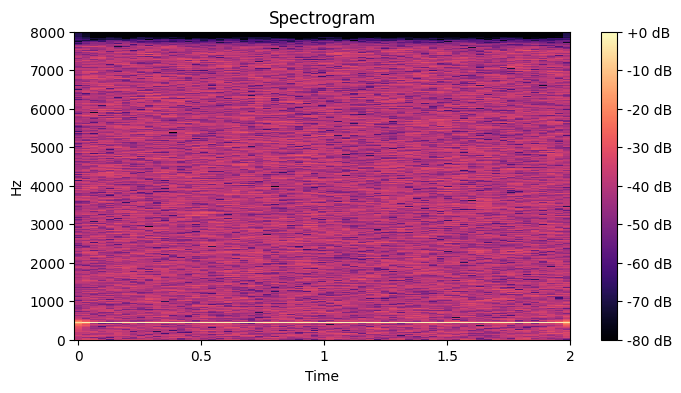

In [ ]:
stft = librosa.stft(waveform_norm)
spectrogram_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)

print("Spectrogram shape (freq_bins, time_frames):", spectrogram_db.shape)

plt.figure(figsize=(8, 4))
librosa.display.specshow(spectrogram_db, sr=target_sr, x_axis="time", y_axis="hz")
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")
plt.show()

## 3.5 Feature Extraction : MFCCs

Mel-Frequency Cepstral Coefficients compress the spectrogram into a compact set of coefficients that approximate human auditory perception — classic input for speech and audio-classification models.

MFCC shape (n_mfcc, time_frames): (13, 63)


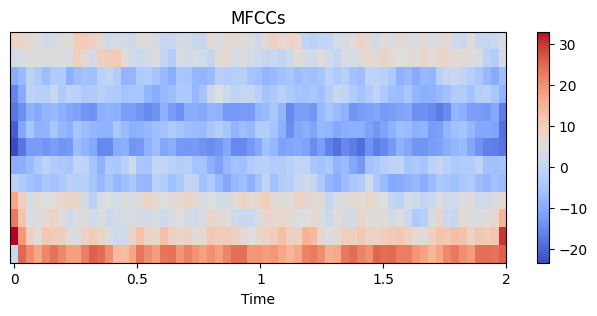

In [ ]:
mfccs = librosa.feature.mfcc(y=waveform_norm, sr=target_sr, n_mfcc=13)
print("MFCC shape (n_mfcc, time_frames):", mfccs.shape)

plt.figure(figsize=(8, 3))
librosa.display.specshow(mfccs, sr=target_sr, x_axis="time")
plt.colorbar()
plt.title("MFCCs")
plt.show()

# Part 4 : Time-Series Data

## 4.1 Creating a Time-Series

Synthetic daily series: upward trend + weekly seasonality + noise, with a few missing timestamps (a very common real-world issue).

2024-01-01    48.387808
2024-01-02    53.500659
2024-01-03    56.361569
2024-01-04    55.245426
2024-01-05    48.410240
2024-01-06    45.614213
2024-01-07          NaN
2024-01-08    53.578314
2024-01-09    56.895680
2024-01-10    60.262087
Freq: D, Name: sales, dtype: float64

Missing values: 6


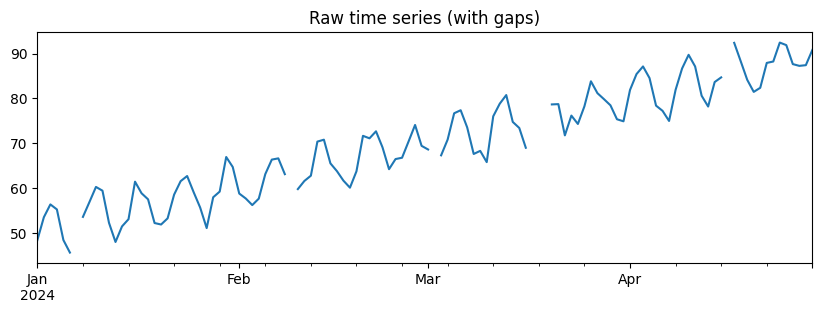

In [ ]:
dates = pd.date_range("2024-01-01", periods=120, freq="D")
trend = np.linspace(50, 90, len(dates))
season = 5 * np.sin(2 * np.pi * dates.dayofweek / 7)
noise = np.random.normal(0, 2, len(dates))

values = trend + season + noise
ts = pd.Series(values, index=dates, name="sales")

# Simulate missing days (e.g. sensor outage / no data recorded)
missing_idx = np.random.choice(len(ts), size=6, replace=False)
ts.iloc[missing_idx] = np.nan

print(ts.head(10))
print("\nMissing values:", ts.isna().sum())

ts.plot(figsize=(10, 3), title="Raw time series (with gaps)")
plt.show()

## 4.2 Resampling

Change the granularity of the series, e.g. daily → weekly average.

2024-01-07    51.253319
2024-01-14    54.550741
2024-01-21    55.454111
2024-01-28    58.081260
2024-02-04    60.173194
Freq: W-SUN, Name: sales, dtype: float64


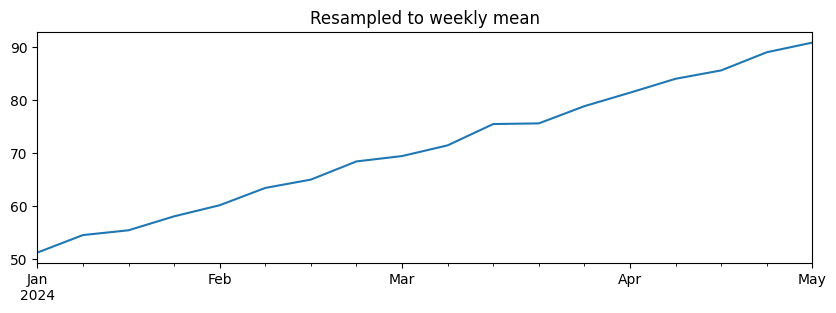

In [ ]:
weekly = ts.resample("W").mean()
print(weekly.head())

weekly.plot(figsize=(10, 3), title="Resampled to weekly mean")
plt.show()

## 4.3 Handling Missing Values : Interpolation

For time-ordered data, linear interpolation (or forward-fill) is usually preferred over dropping rows or filling with the global mean, since it respects trend.

Remaining NaNs after interpolation: 0


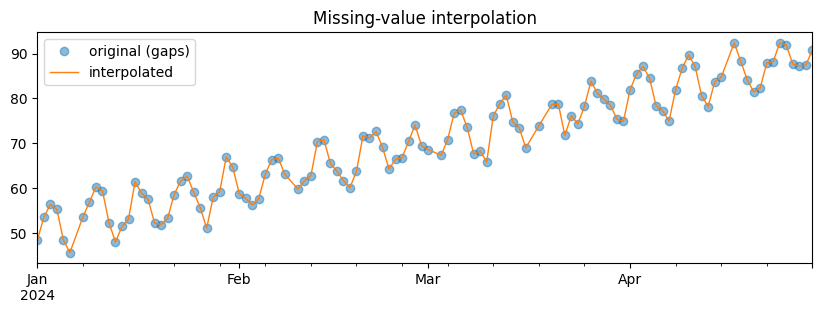

In [ ]:
ts_interpolated = ts.interpolate(method="linear")

print("Remaining NaNs after interpolation:", ts_interpolated.isna().sum())

fig, ax = plt.subplots(figsize=(10, 3))
ts.plot(ax=ax, style="o", label="original (gaps)", alpha=0.5)
ts_interpolated.plot(ax=ax, label="interpolated", linewidth=1)
ax.legend()
ax.set_title("Missing-value interpolation")
plt.show()

## 4.4 Smoothing : Rolling Mean

A rolling/moving average reduces short-term noise so long-term trends are easier to see (and easier for a model to learn from).

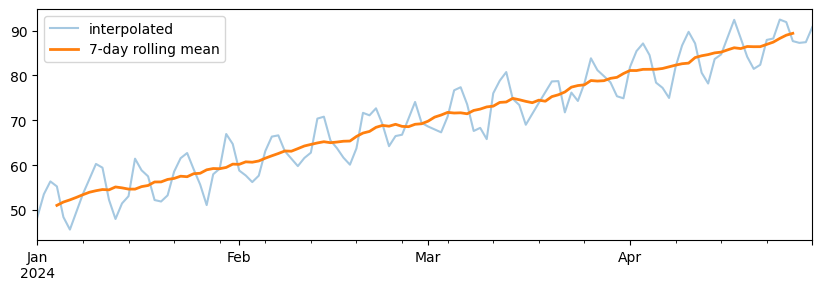

In [ ]:
ts_smooth = ts_interpolated.rolling(window=7, center=True).mean()

fig, ax = plt.subplots(figsize=(10, 3))
ts_interpolated.plot(ax=ax, alpha=0.4, label="interpolated")
ts_smooth.plot(ax=ax, label="7-day rolling mean", linewidth=2)
ax.legend()
plt.show()

## 4.5 Normalization

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
ts_scaled = scaler.fit_transform(ts_interpolated.values.reshape(-1, 1)).flatten()

print("Before scaling: min={:.2f}, max={:.2f}".format(ts_interpolated.min(), ts_interpolated.max()))
print("After scaling : min={:.2f}, max={:.2f}".format(ts_scaled.min(), ts_scaled.max()))

Before scaling: min=45.61, max=92.47
After scaling : min=0.00, max=1.00


## 4.6 Sliding Windows for Supervised Learning

Most time-series models (and all classic ML models) need fixed-size `(X, y)` pairs. A sliding window turns "predict tomorrow from the last N days" into a standard supervised-learning table.

In [ ]:
def make_windows(series, window_size):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i : i + window_size])
        y.append(series[i + window_size])
    return np.array(X), np.array(y)

window_size = 7
X_win, y_win = make_windows(ts_scaled, window_size)

print("X shape (n_samples, window_size):", X_win.shape)
print("y shape (n_samples,)            :", y_win.shape)
print("\nExample window -> target:")
print(X_win[0].round(2), "->", round(y_win[0], 2))

X shape (n_samples, window_size): (113, 7)
y shape (n_samples,)            : (113,)

Example window -> target:
[0.06 0.17 0.23 0.21 0.06 0.   0.08] -> 0.17


## 4.7 Train/Test Split — Respect Time Order

**Never shuffle time-series data before splitting** — that would let the model "see the future". Always split chronologically.

In [ ]:
split_idx = int(len(X_win) * 0.8)

X_train, X_test = X_win[:split_idx], X_win[split_idx:]
y_train, y_test = y_win[:split_idx], y_win[split_idx:]

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (90, 7) Test: (23, 7)


# Part 5 : Tabular Data

## 5.1 A Messy Tabular Dataset

Numeric columns, categorical columns, missing values, and an outlier — a realistic mix.

In [ ]:
df = pd.DataFrame({
    "age":        [21, 22, 20, 23, np.nan, 24, 21, 45],   # 45 is an outlier; one NaN
    "income":     [32000, 41000, np.nan, 39000, 52000, 47000, 30000, 250000],
    "branch":     ["CSE", "CSAI", "CSE", "ECE", "CSAI", "ECE", "CSE", np.nan],
    "city":       ["Delhi", "Mumbai", "Delhi", "Pune", "Mumbai", "Pune", "Delhi", "Delhi"],
    "purchased":  [0, 1, 0, 1, 1, 1, 0, 0],   # target label
})
df

,age,income,branch,city,purchased
0,21.0,32000.0,CSE,Delhi,0
1,22.0,41000.0,CSAI,Mumbai,1
2,20.0,NaN,CSE,Delhi,0
3,23.0,39000.0,ECE,Pune,1
4,NaN,52000.0,CSAI,Mumbai,1
5,24.0,47000.0,ECE,Pune,1
6,21.0,30000.0,CSE,Delhi,0
7,45.0,250000.0,NaN,Delhi,0


## 5.2 Inspecting for Issues

In [ ]:
print(df.dtypes)
print("\nMissing values per column:\n", df.isna().sum())
print("\nSummary stats:\n", df.describe())

age          float64
income       float64
branch        object
city          object
purchased      int64
dtype: object

Missing values per column:
 age          1
income       1
branch       1
city         0
purchased    0
dtype: int64

Summary stats:
              age         income  purchased
count   7.000000       7.000000   8.000000
mean   25.142857   70142.857143   0.500000
std     8.858679   79685.692090   0.534522
min    20.000000   30000.000000   0.000000
25%    21.000000   35500.000000   0.000000
50%    22.000000   41000.000000   0.500000
75%    23.500000   49500.000000   1.000000
max    45.000000  250000.000000   1.000000


## 5.3 Missing-Value Imputation

* Numeric → median (robust to outliers) or mean
* Categorical → most-frequent category, or an explicit "Unknown" label

In [ ]:
from sklearn.impute import SimpleImputer

num_cols = ["age", "income"]
cat_cols = ["branch", "city"]

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

df_imputed = df.copy()
df_imputed[num_cols] = num_imputer.fit_transform(df[num_cols])
df_imputed[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

df_imputed

,age,income,branch,city,purchased
0,21.0,32000.0,CSE,Delhi,0
1,22.0,41000.0,CSAI,Mumbai,1
2,20.0,41000.0,CSE,Delhi,0
3,23.0,39000.0,ECE,Pune,1
4,22.0,52000.0,CSAI,Mumbai,1
5,24.0,47000.0,ECE,Pune,1
6,21.0,30000.0,CSE,Delhi,0
7,45.0,250000.0,CSE,Delhi,0


## 5.4 Encoding Categorical Columns

* **One-Hot Encoding** — for unordered (nominal) categories, e.g. `city`
* **Label/Ordinal Encoding** — for ordered categories, or when a tree-based model will consume the feature

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, drop="first")
branch_city_encoded = ohe.fit_transform(df_imputed[cat_cols])

encoded_cols = ohe.get_feature_names_out(cat_cols)
df_encoded = pd.DataFrame(branch_city_encoded, columns=encoded_cols, index=df_imputed.index)

df_final_cat = pd.concat([df_imputed.drop(columns=cat_cols), df_encoded], axis=1)
df_final_cat

,age,income,purchased,branch_CSE,branch_ECE,city_Mumbai,city_Pune
0,21.0,32000.0,0,1.0,0.0,0.0,0.0
1,22.0,41000.0,1,0.0,0.0,1.0,0.0
2,20.0,41000.0,0,1.0,0.0,0.0,0.0
3,23.0,39000.0,1,0.0,1.0,0.0,1.0
4,22.0,52000.0,1,0.0,0.0,1.0,0.0
5,24.0,47000.0,1,0.0,1.0,0.0,1.0
6,21.0,30000.0,0,1.0,0.0,0.0,0.0
7,45.0,250000.0,0,1.0,0.0,0.0,0.0


## 5.5 Feature Scaling

`age` and `income` are on very different scales — many models (KNN, SVM, gradient descent–based models) need them standardized.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = df_final_cat.copy()
df_scaled[num_cols] = scaler.fit_transform(df_final_cat[num_cols])

df_scaled

,age,income,purchased,branch_CSE,branch_ECE,city_Mumbai,city_Pune
0,-0.484375,-0.495123,0,1.0,0.0,0.0,0.0
1,-0.355209,-0.365961,1,0.0,0.0,1.0,0.0
2,-0.613542,-0.365961,0,1.0,0.0,0.0,0.0
3,-0.226042,-0.394663,1,0.0,1.0,0.0,1.0
4,-0.355209,-0.208095,1,0.0,0.0,1.0,0.0
5,-0.096875,-0.279852,1,0.0,1.0,0.0,1.0
6,-0.484375,-0.523826,0,1.0,0.0,0.0,0.0
7,2.615626,2.633481,0,1.0,0.0,0.0,0.0


## 5.6 Putting It Together: `ColumnTransformer` + `Pipeline`

Instead of chaining these steps manually (error-prone, and easy to leak information from test to train), scikit-learn lets us bundle everything into a single, reusable `Pipeline` that is fit **only on the training data**.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

X = df.drop(columns=["purchased"])
y = df["purchased"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols),
])

# Fit ONLY on training data, then transform both train and test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape :", X_test_processed.shape)
print("\nFeature names out:", preprocessor.get_feature_names_out())

X_train_processed shape: (6, 8)
X_test_processed shape : (2, 8)

Feature names out: ['num__age' 'num__income' 'cat__branch_CSAI' 'cat__branch_CSE'
 'cat__branch_ECE' 'cat__city_Delhi' 'cat__city_Mumbai' 'cat__city_Pune']
